### IPL DATA ANALYSIS USING S3 BUCKET AND SPARK

In [0]:
from pyspark.sql.types import StructType, StringType, IntegerType, StructField, DateType,BooleanType,DecimalType
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.sql import *

In [0]:
from pyspark.sql import SparkSession as ss
# create spark session
spark = ss.builder.appName("weather_analysis").getOrCreate()


In [0]:
ball_schema = StructType([
    StructField("match_id", IntegerType(), True),
    StructField("over_id", IntegerType(), True),
    StructField("ball_id", IntegerType(), True),
    StructField("innings_no", IntegerType(), True),
    StructField("team_batting", StringType(), True),
    StructField("team_bowling", StringType(), True),
    StructField("striker_batting_position", IntegerType(), True),
    StructField("extra_type", StringType(), True),
    StructField("runs_scored", IntegerType(), True),
    StructField("extra_runs", IntegerType(), True),
    StructField("wides", IntegerType(), True),
    StructField("legbyes", IntegerType(), True),
    StructField("byes", IntegerType(), True),
    StructField("noballs", IntegerType(), True),
    StructField("penalty", IntegerType(), True),
    StructField("bowler_extras", IntegerType(), True),
    StructField("out_type", StringType(), True),
    StructField("caught", BooleanType(), True),
    StructField("bowled", BooleanType(), True),
    StructField("run_out", BooleanType(), True),
    StructField("lbw", BooleanType(), True),
    StructField("retired_hurt", BooleanType(), True),
    StructField("stumped", BooleanType(), True),
    StructField("caught_and_bowled", BooleanType(), True),
    StructField("hit_wicket", BooleanType(), True),
    StructField("obstructingfeild", BooleanType(), True),
    StructField("bowler_wicket", BooleanType(), True),
    StructField("match_date", DateType(), True),
    StructField("season", IntegerType(), True),
    StructField("striker", IntegerType(), True),
    StructField("non_striker", IntegerType(), True),
    StructField("bowler", IntegerType(), True),
    StructField("player_out", IntegerType(), True),
    StructField("fielders", IntegerType(), True),
    StructField("striker_match_sk", IntegerType(), True),
    StructField("strikersk", IntegerType(), True),
    StructField("nonstriker_match_sk", IntegerType(), True),
    StructField("nonstriker_sk", IntegerType(), True),
    StructField("fielder_match_sk", IntegerType(), True),
    StructField("fielder_sk", IntegerType(), True),
    StructField("bowler_match_sk", IntegerType(), True),
    StructField("bowler_sk", IntegerType(), True),
    StructField("playerout_match_sk", IntegerType(), True),
    StructField("battingteam_sk", IntegerType(), True),
    StructField("bowlingteam_sk", IntegerType(), True),
    StructField("keeper_catch", BooleanType(), True),
    StructField("player_out_sk", IntegerType(), True),
    StructField("matchdatesk", DateType(), True)
])

In [0]:
# display the the ball_data schema 
ball_by = spark.read.schema(ball_schema).format("csv").option("header", "true").load("s3://ipl-data-analysis-project/Ball_By_Ball.csv")

In [0]:
# Display the data from s3 bucket
ball_by.show(5)


+--------+-------+-------+----------+------------+------------+------------------------+----------+-----------+----------+-----+-------+----+-------+-------+-------------+--------------+------+------+-------+----+------------+-------+-----------------+----------+----------------+-------------+----------+------+-------+-----------+------+----------+--------+----------------+---------+-------------------+-------------+----------------+----------+---------------+---------+------------------+--------------+--------------+------------+-------------+-----------+
|match_id|over_id|ball_id|innings_no|team_batting|team_bowling|striker_batting_position|extra_type|runs_scored|extra_runs|wides|legbyes|byes|noballs|penalty|bowler_extras|      out_type|caught|bowled|run_out| lbw|retired_hurt|stumped|caught_and_bowled|hit_wicket|obstructingfeild|bowler_wicket|match_date|season|striker|non_striker|bowler|player_out|fielders|striker_match_sk|strikersk|nonstriker_match_sk|nonstriker_sk|fielder_match_sk|

In [0]:
# write  the code for match_data schema  
match_schema = StructType([
    StructField("match_sk", IntegerType(), True),
    StructField("match_id", IntegerType(), True),
    StructField("team1", StringType(), True),
    StructField("team2", StringType(), True),
    StructField("match_date", DateType(), True),
    StructField("season_year", IntegerType(), True),
    StructField("venue_name", StringType(), True),
    StructField("city_name", StringType(), True),
    StructField("country_name", StringType(), True),
    StructField("toss_winner", StringType(), True),
    StructField("match_winner", StringType(), True),
    StructField("toss_name", StringType(), True),
    StructField("win_type", StringType(), True),
    StructField("outcome_type", StringType(), True),
    StructField("manofmach", StringType(), True),
    StructField("win_margin", IntegerType(), True),
    StructField("country_id", IntegerType(), True)
])



In [0]:
# extract the data of match_data from s3 bucket and match the custome schema 
match_df = spark.read.schema(match_schema).format("csv").option("header","true").load("s3://ipl-data-analysis-project/Match.csv")

In [0]:
# write the code or schema for the player_data 
player_schema = StructType([
    StructField("player_sk", IntegerType(), True),
    StructField("player_id", IntegerType(), True),
    StructField("player_name", StringType(), True),
    StructField("dob", DateType(), True),
    StructField("batting_hand", StringType(), True),
    StructField("bowling_skill", StringType(), True),
    StructField("country_name", StringType(), True)
])


In [0]:
# extract the data of player_data from s3 bucket and match the custome schema 
player_df = spark.read.schema(player_schema).format("csv").option("header","true").load("s3://ipl-data-analysis-project/Player.csv")



In [0]:
# write the code for the player_match_schema 
player_match_schema = StructType([
    StructField("player_match_sk", IntegerType(), True),
    StructField("playermatch_key", DecimalType(), True),
    StructField("match_id", IntegerType(), True),
    StructField("player_id", IntegerType(), True),
    StructField("player_name", StringType(), True),
    StructField("dob", DateType(), True),
    StructField("batting_hand", StringType(), True),
    StructField("bowling_skill", StringType(), True),
    StructField("country_name", StringType(), True),
    StructField("role_desc", StringType(), True),
    StructField("player_team", StringType(), True),
    StructField("opposit_team", StringType(), True),
    StructField("season_year", IntegerType(), True),
    StructField("is_manofthematch", BooleanType(), True),
    StructField("age_as_on_match", IntegerType(), True),
    StructField("isplayers_team_won", BooleanType(), True),
    StructField("batting_status", StringType(), True),
    StructField("bowling_status", StringType(), True),
    StructField("player_captain", StringType(), True),
    StructField("opposit_captain", StringType(), True),
    StructField("player_keeper", StringType(), True),
    StructField("opposit_keeper", StringType(), True)
])

player_match_df = spark.read.schema(player_match_schema).format("csv").option("header","true").load(
    "s3://ipl-data-analysis-project/Player_match.csv",
    header=True, 
    inferSchema=True
)



In [0]:
team_schema = StructType([
    StructField("team_sk", IntegerType(), True),
    StructField("team_id", IntegerType(), True),
    StructField("team_name", StringType(), True)
])

team_df = spark.read.schema(team_schema).format("csv").option("header","true").load("s3://ipl-data-analysis-project/Team.csv")

In [0]:
# filter to include the vaild_deliverys
ball_by = ball_by.filter((col("wides")==0) & (col("noballs")==0))
ball_by.show()


+--------+-------+-------+----------+------------+------------+------------------------+----------+-----------+----------+-----+-------+----+-------+-------+-------------+--------------+------+------+-------+----+------------+-------+-----------------+----------+----------------+-------------+----------+------+-------+-----------+------+----------+--------+----------------+---------+-------------------+-------------+----------------+----------+---------------+---------+------------------+--------------+--------------+------------+-------------+-----------+
|match_id|over_id|ball_id|innings_no|team_batting|team_bowling|striker_batting_position|extra_type|runs_scored|extra_runs|wides|legbyes|byes|noballs|penalty|bowler_extras|      out_type|caught|bowled|run_out| lbw|retired_hurt|stumped|caught_and_bowled|hit_wicket|obstructingfeild|bowler_wicket|match_date|season|striker|non_striker|bowler|player_out|fielders|striker_match_sk|strikersk|nonstriker_match_sk|nonstriker_sk|fielder_match_sk|

In [0]:
# Aggregation : calculate the total and average runs scored in each match and innings
total_and_avg_runs = ball_by.groupBy("match_id","innings_no").agg(
    sum("runs_scored").alias("total_runs"),
    avg("runs_scored").alias("avg_runs")
)
total_and_avg_runs.show()

+--------+----------+----------+------------------+
|match_id|innings_no|total_runs|          avg_runs|
+--------+----------+----------+------------------+
|  548360|         2|       171|             1.425|
|  501223|         1|       104|               1.0|
|  980968|         2|       145|1.2083333333333333|
|  336043|         2|        80|0.8247422680412371|
|  548320|         1|       159|             1.325|
| 1082644|         1|       156|               1.3|
|  419163|         2|       126|1.2989690721649485|
|  548322|         1|       191|1.5916666666666666|
|  980910|         2|       156| 1.471698113207547|
|  501247|         2|       136|1.1333333333333333|
|  733996|         2|       154|1.2833333333333334|
|  548357|         2|       146|1.2166666666666666|
|  336025|         1|       186|              1.55|
|  829712|         2|       144|               1.2|
|  829720|         1|       175|1.4583333333333333|
|  548382|         2|       144|1.3333333333333333|
|  501233|  

In [0]:
# window functions : Calculate the running total of runs in each match and each over 
Window_bucket = Window.partitionBy("match_id","innings_no").orderBy("over_id")

# create the new column 
ball_by = ball_by.withColumn("running_total_runs",
sum("runs_scored").over(Window_bucket))

# display the new column
ball_by.show()

+--------+-------+-------+----------+------------+------------+------------------------+----------+-----------+----------+-----+-------+----+-------+-------+-------------+--------------+------+------+-------+----+------------+-------+-----------------+----------+----------------+-------------+----------+------+-------+-----------+------+----------+--------+----------------+---------+-------------------+-------------+----------------+----------+---------------+---------+------------------+--------------+--------------+------------+-------------+-----------+------------------+
|match_id|over_id|ball_id|innings_no|team_batting|team_bowling|striker_batting_position|extra_type|runs_scored|extra_runs|wides|legbyes|byes|noballs|penalty|bowler_extras|      out_type|caught|bowled|run_out| lbw|retired_hurt|stumped|caught_and_bowled|hit_wicket|obstructingfeild|bowler_wicket|match_date|season|striker|non_striker|bowler|player_out|fielders|striker_match_sk|strikersk|nonstriker_match_sk|nonstriker_s

In [0]:
# Conditional column : flags for high impact balls

ball_by = ball_by.withColumn("high_impact_balls",
                             when((col("runs_scored")+col("extra_runs")>6)| (col("bowler_wicket")==True), True).otherwise(False)
                             ) 

# display the Another new column
ball_by.show()


+--------+-------+-------+----------+------------+------------+------------------------+----------+-----------+----------+-----+-------+----+-------+-------+-------------+--------------+------+------+-------+----+------------+-------+-----------------+----------+----------------+-------------+----------+------+-------+-----------+------+----------+--------+----------------+---------+-------------------+-------------+----------------+----------+---------------+---------+------------------+--------------+--------------+------------+-------------+-----------+------------------+-----------------+
|match_id|over_id|ball_id|innings_no|team_batting|team_bowling|striker_batting_position|extra_type|runs_scored|extra_runs|wides|legbyes|byes|noballs|penalty|bowler_extras|      out_type|caught|bowled|run_out| lbw|retired_hurt|stumped|caught_and_bowled|hit_wicket|obstructingfeild|bowler_wicket|match_date|season|striker|non_striker|bowler|player_out|fielders|striker_match_sk|strikersk|nonstriker_mat

In [0]:
# Extracting year, month, and day from the match date for more detailed time-based analysis
match_df = match_df.withColumn("year", year("match_date"))
match_df = match_df.withColumn("month", month("match_date"))
match_df = match_df.withColumn("day", dayofmonth("match_date"))

# High margin win: categorizing win margins into 'high', 'medium', and 'low'
match_df = match_df.withColumn(
    "win_margin_category",
    when(col("win_margin") >= 100, "High")
    .when((col("win_margin") >= 50) & (col("win_margin") < 100), "Medium")
    .otherwise("Low")
)

# Analyze the impact of the toss: who wins the toss and the match
match_df = match_df.withColumn(
    "toss_match_winner",
    when(col("toss_winner") == col("match_winner"), "Yes").otherwise("No")
)

# Show the enhanced match DataFrame
match_df.show(2)

+--------+--------+--------------------+--------------------+----------+-----------+--------------------+----------+------------+--------------------+--------------------+---------+--------+------------+-----------+----------+----------+----+-----+----+-------------------+-----------------+
|match_sk|match_id|               team1|               team2|match_date|season_year|          venue_name| city_name|country_name|         toss_winner|        match_winner|toss_name|win_type|outcome_type|  manofmach|win_margin|country_id|year|month| day|win_margin_category|toss_match_winner|
+--------+--------+--------------------+--------------------+----------+-----------+--------------------+----------+------------+--------------------+--------------------+---------+--------+------------+-----------+----------+----------+----+-----+----+-------------------+-----------------+
|       0|  335987|Royal Challengers...|Kolkata Knight Ri...|      NULL|       2008|M Chinnaswamy Sta...| Bangalore|       I

In [0]:
# Normalize and clean the player name 
player_df = player_df.withColumn("player_name",lower(regexp_replace("player_name","[^a-zA-Z0-9]","")))

# Hnadle the missing value in "batting_hand" and "bowling_skills" with a default 'unknown'

player_df = player_df.na.fill({"batting_hand":"unknown","bowling_skill":"unknown"})

# catego player based on batting hand
palyer_df = player_df.withColumn("batting_style",when(col("batting_hand").contains("left"),"LEFT-HANDED").otherwise("RIGHT-HANDED"))

# display the new columns in player data 
player_df.show()


+---------+---------+--------------+----+--------------+--------------------+------------+
|player_sk|player_id|   player_name| dob|  batting_hand|       bowling_skill|country_name|
+---------+---------+--------------+----+--------------+--------------------+------------+
|        0|        1|     scganguly|NULL| Left-hand bat|    Right-arm medium|       India|
|        1|        2|    bbmccullum|NULL|Right-hand bat|    Right-arm medium| New Zealand|
|        2|        3|     rtponting|NULL|Right-hand bat|    Right-arm medium|   Australia|
|        3|        4|      djhussey|NULL|Right-hand bat|  Right-arm offbreak|   Australia|
|        4|        5|mohammadhafeez|NULL|Right-hand bat|  Right-arm offbreak|    Pakistan|
|        5|        6|       rdravid|NULL|Right-hand bat|  Right-arm offbreak|       India|
|        6|        7|       wjaffer|NULL|Right-hand bat|  Right-arm offbreak|       India|
|        7|        8|        vkohli|NULL|Right-hand bat|    Right-arm medium|       India|

In [0]:
# Add the veteran status based on players age
player_match_df  = player_match_df.withColumn("Veteran_status",when(col("age_as_on_match")>=35,"Veteran").otherwise("Non-Veteran")) 

# filter to include the player who played the match
player_match_df = player_match_df.filter(col("batting_status")!= "Did Not Bat")


# Dynamic column to calculate the years since debut
player_match_df = player_match_df.withColumn(
    "years_since_debut",
    (year(current_date())-col("season_year")))


# display the player match data with newly added column
player_match_df.show()

+---------------+---------------+--------+---------+-----------+---+------------+-------------+------------+---------+-----------+------------+-----------+----------------+---------------+------------------+--------------+--------------+--------------+---------------+-------------+--------------+--------------+-----------------+
|player_match_sk|playermatch_key|match_id|player_id|player_name|dob|batting_hand|bowling_skill|country_name|role_desc|player_team|opposit_team|season_year|is_manofthematch|age_as_on_match|isplayers_team_won|batting_status|bowling_status|player_captain|opposit_captain|player_keeper|opposit_keeper|Veteran_status|years_since_debut|
+---------------+---------------+--------+---------+-----------+---+------------+-------------+------------+---------+-----------+------------+-----------+----------------+---------------+------------------+--------------+--------------+--------------+---------------+-------------+--------------+--------------+-----------------+
+------

In [0]:
player_match_df = spark.read.csv(
    "s3://ipl-data-analysis-project/Player_match.csv",
    header=True, 
    inferSchema=True
)


In [0]:
ball_by.createOrReplaceTempView("ball_by_ball")
match_df.createOrReplaceTempView("match")
player_df.createOrReplaceTempView("player")
player_match_df.createOrReplaceTempView("player_match")
team_df.createOrReplaceTempView("team")

In [0]:
player_match_df.printSchema()

root
 |-- Player_match_SK: integer (nullable = true)
 |-- PlayerMatch_key: double (nullable = true)
 |-- Match_Id: integer (nullable = true)
 |-- Player_Id: integer (nullable = true)
 |-- Player_Name: string (nullable = true)
 |-- DOB: date (nullable = true)
 |-- Batting_hand: string (nullable = true)
 |-- Bowling_skill: string (nullable = true)
 |-- Country_Name: string (nullable = true)
 |-- Role_Desc: string (nullable = true)
 |-- Player_team: string (nullable = true)
 |-- Opposit_Team: string (nullable = true)
 |-- Season_year: integer (nullable = true)
 |-- is_manofThematch: integer (nullable = true)
 |-- Age_As_on_match: integer (nullable = true)
 |-- IsPlayers_Team_won: integer (nullable = true)
 |-- Batting_Status: string (nullable = true)
 |-- Bowling_Status: string (nullable = true)
 |-- Player_Captain: string (nullable = true)
 |-- Opposit_captain: string (nullable = true)
 |-- Player_keeper: string (nullable = true)
 |-- Opposit_keeper: string (nullable = true)



TOP SCORING BATSMAN PRE SEASON


In [0]:
spark.sql("""
SELECT 
p.player_name,
m.season_year,
SUM(b.runs_scored) AS total_runs 
FROM ball_by_ball b
JOIN match m ON b.match_id = m.match_id   
JOIN player_match pm ON m.match_id = pm.match_id AND b.striker = pm.player_id     
JOIN player p ON p.player_id = pm.player_id
GROUP BY p.player_name, m.season_year
ORDER BY m.season_year, total_runs DESC
""").show(30)

+-------------+-----------+----------+
|  player_name|season_year|total_runs|
+-------------+-----------+----------+
|      semarsh|       2008|       614|
|     ggambhir|       2008|       532|
| stjayasuriya|       2008|       508|
|     srwatson|       2008|       463|
|      gcsmith|       2008|       437|
|  acgilchrist|       2008|       431|
|     ykpathan|       2008|       430|
|      skraina|       2008|       420|
|      msdhoni|       2008|       414|
|     rgsharma|       2008|       399|
|      vsehwag|       2008|       399|
|      rdravid|       2008|       370|
|    scganguly|       2008|       349|
|      sdhawan|       2008|       340|
| kcsangakkara|       2008|       319|
|     djhussey|       2008|       318|
|    rvuthappa|       2008|       316|
|   saasnodkar|       2008|       311|
|  yuvrajsingh|       2008|       299|
|      papatel|       2008|       297|
|yvenugopalrao|       2008|       283|
|     jamorkel|       2008|       235|
|    mvboucher|       200

MOST ECONOMICAL BOWLERS IN POWERPLAY

In [0]:
economical_bowlers_powerplay = spark.sql("""
SELECT 
    p.player_name,
    AVG(b.runs_scored) AS Avg_runs_per_ball,
    COUNT(b.bowler_wicket) AS total_wickets
FROM ball_by_ball b  
JOIN player_match pm 
    ON b.match_id = pm.match_id  
    AND b.bowler = pm.player_id
JOIN player p 
    ON pm.player_id = p.player_id
WHERE b.over_id <= 6
GROUP BY p.player_name 
HAVING COUNT(*) > 120
ORDER BY Avg_runs_per_ball ASC, total_wickets DESC
""")

In [0]:
economical_bowlers_powerplay.show()

+--------------+------------------+-------------+
|   player_name| Avg_runs_per_ball|total_wickets|
+--------------+------------------+-------------+
|smsmsenanayake|0.8492063492063492|            0|
|      spnarine| 0.929718875502008|            0|
|     gdmcgrath|0.9324324324324325|            0|
|     slmalinga|0.9407630522088354|            0|
|  sohailtanvir| 0.946969696969697|            0|
|     achandila|0.9513888888888888|            0|
|      dpnannes|0.9532163742690059|            0|
|        bkumar|0.9561487130600572|            0|
|  bwhilfenhaus|            0.9625|            0|
|      rrampaul|0.9629629629629629|            0|
|       dwsteyn|0.9700374531835206|            0|
|       rashwin|0.9729344729344729|            0|
|     smpollock|1.0049019607843137|            0|
|   ankitsharma|1.0072463768115942|            0|
|      rjharris|1.0093896713615023|            0|
|     wpujcvaas|1.0151515151515151|            0|
|      acthomas|1.0277777777777777|            0|


TOSS IMPACT IN INDIVIDUAL MATCHES

In [0]:
toss_impact_individual_matches = spark.sql("""
SELECT 
    m.match_id,
    m.toss_winner,
    m.toss_name,
    m.match_winner,
    CASE 
        WHEN m.toss_winner = m.match_winner THEN 'Won' 
        ELSE 'Lost' 
    END AS match_outcome
FROM match m
WHERE m.toss_name IS NOT NULL
ORDER BY m.match_id
""")

toss_impact_individual_matches.show()

+--------+--------------------+---------+--------------------+-------------+
|match_id|         toss_winner|toss_name|        match_winner|match_outcome|
+--------+--------------------+---------+--------------------+-------------+
|  335987|Royal Challengers...|    field|Kolkata Knight Ri...|         Lost|
|  335988| Chennai Super Kings|      bat| Chennai Super Kings|          Won|
|  335989|    Rajasthan Royals|      bat|    Delhi Daredevils|         Lost|
|  335990|      Mumbai Indians|      bat|Royal Challengers...|         Lost|
|  335991|     Deccan Chargers|      bat|Kolkata Knight Ri...|         Lost|
|  335992|     Kings XI Punjab|      bat|    Rajasthan Royals|         Lost|
|  335993|     Deccan Chargers|      bat|    Delhi Daredevils|         Lost|
|  335994|      Mumbai Indians|    field| Chennai Super Kings|         Lost|
|  335995|    Rajasthan Royals|    field|    Rajasthan Royals|          Won|
|  335996|      Mumbai Indians|    field|     Kings XI Punjab|         Lost|

AVERAGE RUNS SCORDED BY TO WIN

In [0]:
average_runs_in_wins = spark.sql("""
SELECT p.player_name, AVG(b.runs_scored) AS avg_runs_in_wins, COUNT(*) AS innings_played
FROM ball_by_ball b
JOIN player_match pm ON b.match_id = pm.match_id AND b.striker = pm.player_id
JOIN player p ON pm.player_id = p.player_id
JOIN match m ON pm.match_id = m.match_id
WHERE m.match_winner = pm.player_team
GROUP BY p.player_name
ORDER BY avg_runs_in_wins ASC
""")
average_runs_in_wins.show()

+------------+-------------------+--------------+
| player_name|   avg_runs_in_wins|innings_played|
+------------+-------------------+--------------+
|     tsmills|                0.0|             3|
|   kpappanna|                0.0|             1|
|     isharma|                0.0|             1|
|     vraaron|                0.0|             5|
|      anehra|                0.0|             2|
|    jjbumrah|                0.0|             2|
|     jtheron|                0.0|             1|
|    snthakur|                0.0|             2|
|anirudhsingh|                0.0|             1|
|   tthushara|                0.2|             5|
|    saabbott|               0.25|             4|
|yashpalsingh| 0.3157894736842105|            19|
|  ssreesanth| 0.3333333333333333|             3|
|  kccariappa| 0.3333333333333333|             3|
|   jdunadkat|                0.4|             5|
|   smharwood|0.42857142857142855|             7|
|      jmkemp|                0.5|             8|


ECONOMICAL BOWLERS ANALYSIS

In [0]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

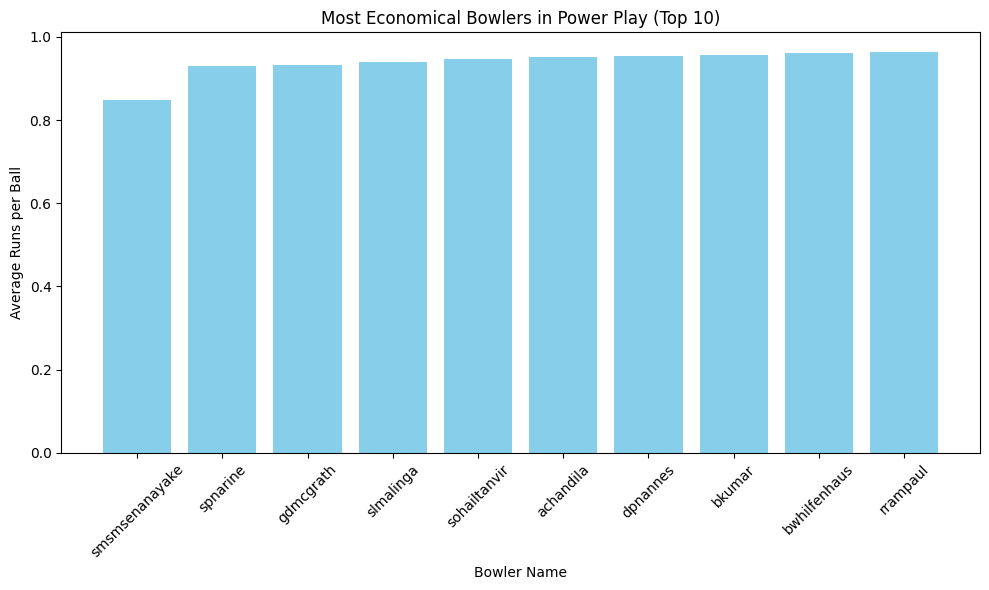

In [0]:
# convert Spark DataFrame to Pandas
economical_bowlers_pd = economical_bowlers_powerplay.toPandas()

# optionally, take top 10 bowlers
top_10 = economical_bowlers_pd.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10['player_name'], top_10['Avg_runs_per_ball'], color='skyblue')
plt.xlabel('Bowler Name')
plt.ylabel('Average Runs per Ball')
plt.title('Most Economical Bowlers in Power Play (Top 10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

IMPACT ON TOSS  DURING MATCHES

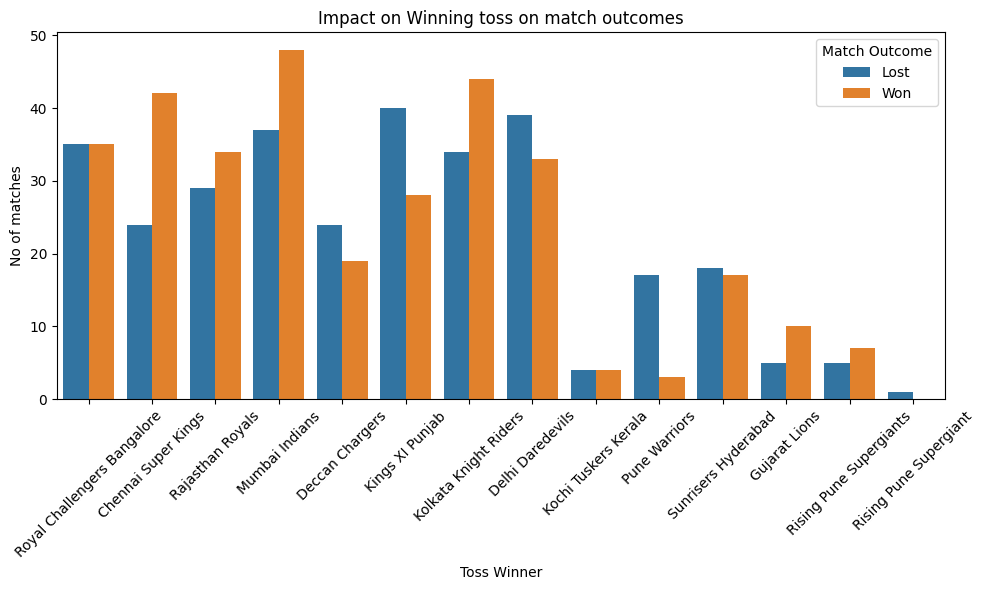

In [0]:
toss_match_df = toss_impact_individual_matches.toPandas()
plt.figure(figsize=(10, 6))
sns.countplot(x='toss_winner',hue='match_outcome', data=toss_match_df)
plt.xlabel('Toss Winner')
plt.ylabel('No of matches')
plt.title('Impact on Winning toss on match outcomes')
plt.legend(title='Match Outcome')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


AVERAGE RUNS IN WINS ANALYSIS

/home/spark-76463625-474e-4127-bd49-79/.ipykernel/4089/command-6699853669779434-2799432862:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x='player_name',


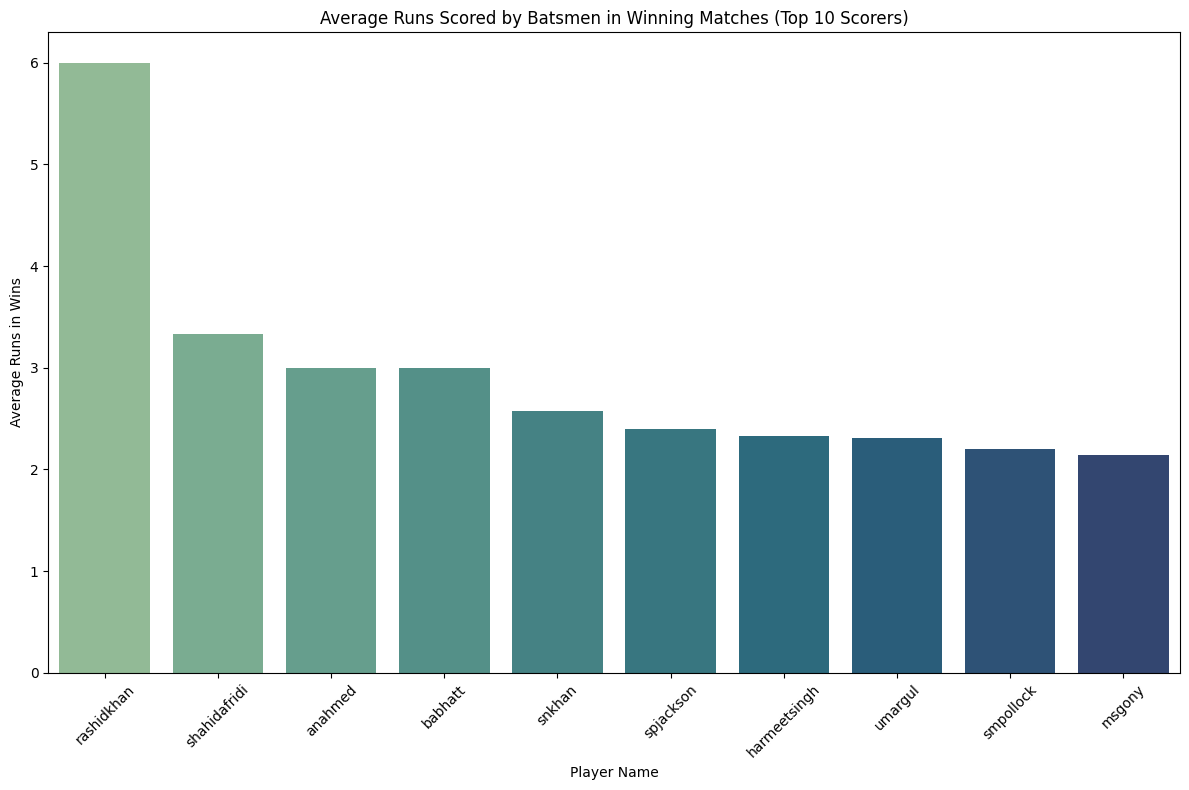

In [0]:
average_runs_pd = average_runs_in_wins.toPandas()

# Using seaborn to plot average runs in winning matches
plt.figure(figsize=(12, 8))
top_scorers = average_runs_pd.nlargest(10, 'avg_runs_in_wins')
sns.barplot( x='player_name',
    y='avg_runs_in_wins',
    data=top_scorers,
    palette='crest')
plt.title('Average Runs Scored by Batsmen in Winning Matches (Top 10 Scorers)')
plt.xlabel('Player Name')
plt.ylabel('Average Runs in Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


SCORED BY VENUE 

In [0]:
# Execute SQL Query
scores_by_venue = spark.sql("""
SELECT venue_name, AVG(total_runs) AS average_score, MAX(total_runs) AS highest_score
FROM (
    SELECT ball_by_ball.match_id, match.venue_name, SUM(runs_scored) AS total_runs
    FROM ball_by_ball
    JOIN match ON ball_by_ball.match_id = match.match_id
    GROUP BY ball_by_ball.match_id, match.venue_name
)
GROUP BY venue_name
ORDER BY average_score DESC
""")

DISMISSAL TYPES 

/home/spark-76463625-474e-4127-bd49-79/.ipykernel/4089/command-4740179320537204-2995780460:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


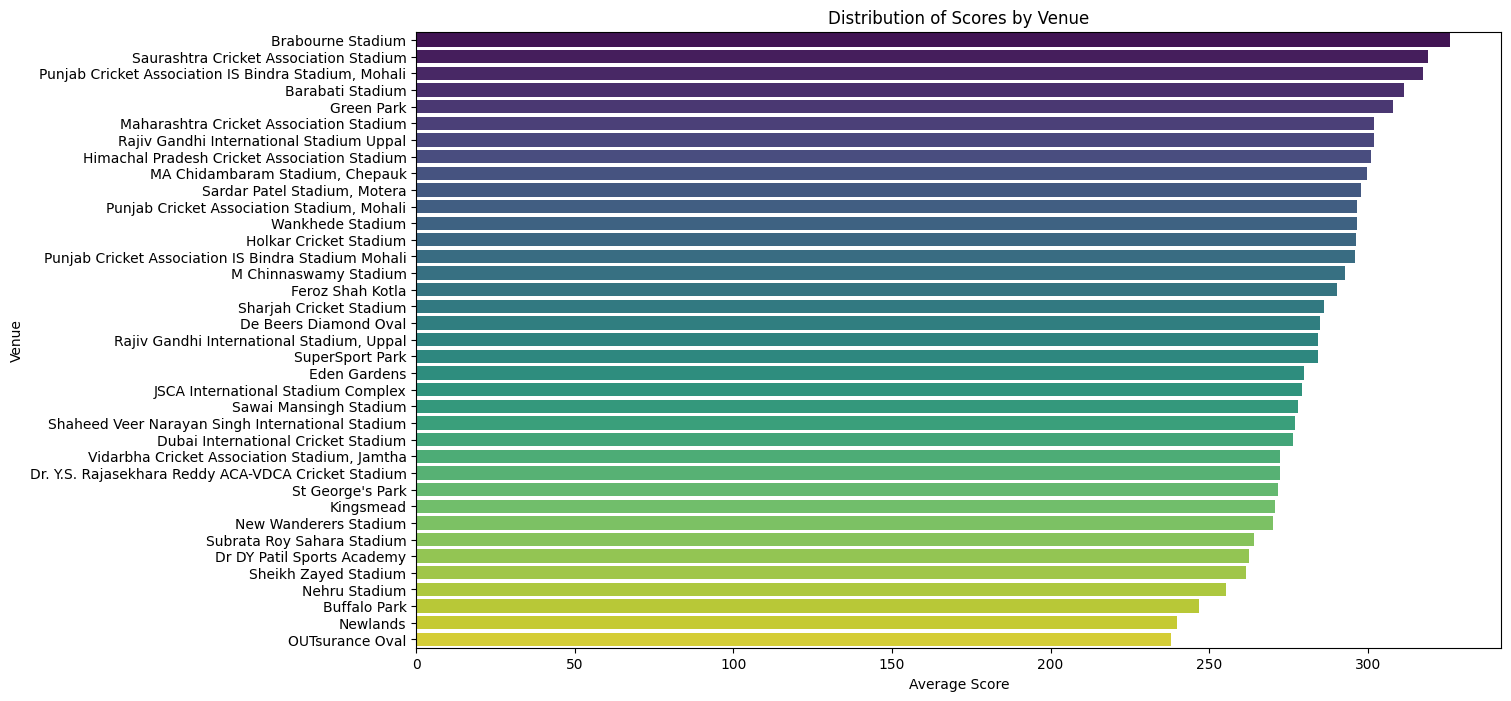

In [0]:
plt.figure(figsize=(14, 8))

sns.barplot(
    x='average_score',
    y='venue_name',
    data=scores_by_venue.toPandas(),
    palette='viridis'   
)

plt.title('Distribution of Scores by Venue')
plt.xlabel('Average Score')
plt.ylabel('Venue')
plt.show()

In [0]:
dismissal_types = spark.sql("""
SELECT out_type, COUNT(*) AS frequency
FROM ball_by_ball
WHERE out_type IS NOT NULL
GROUP BY out_type
ORDER BY frequency DESC
""")


/home/spark-76463625-474e-4127-bd49-79/.ipykernel/4089/command-6699853669779440-2651080675:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency', y='out_type', data=dismissal_types_pd, palette='pastel')


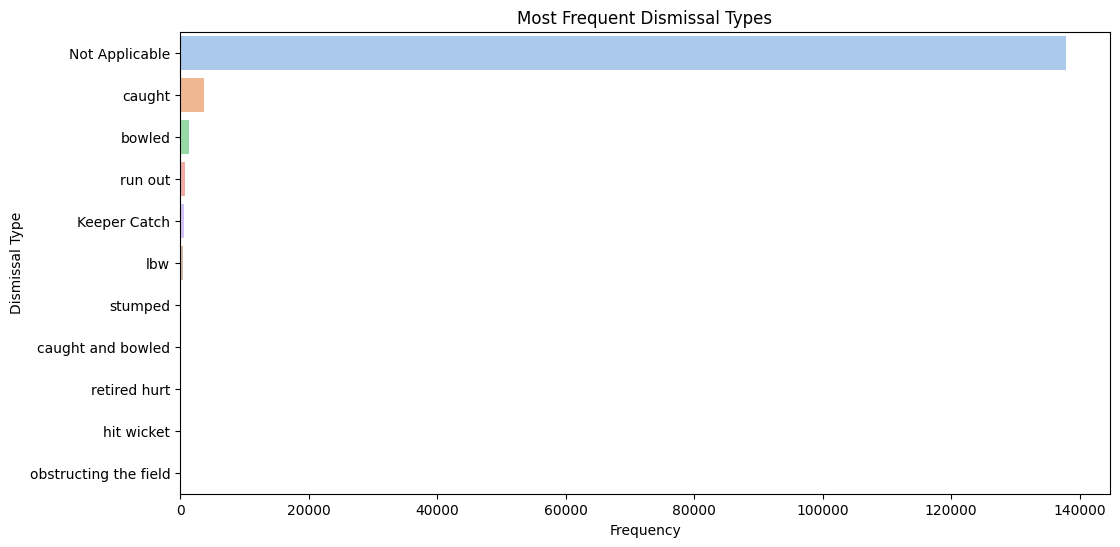

In [0]:
# Convert to Pandas DataFrame
dismissal_types_pd = dismissal_types.toPandas()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='frequency', y='out_type', data=dismissal_types_pd, palette='pastel')
plt.title('Most Frequent Dismissal Types')
plt.xlabel('Frequency')
plt.ylabel('Dismissal Type')
plt.show()
     

TEAM TOSS WIN PERFORMANCE 

In [0]:
# Execute SQL Query
team_toss_win_performance = spark.sql("""
SELECT team1, COUNT(*) AS matches_played, SUM(CASE WHEN toss_winner = match_winner THEN 1 ELSE 0 END) AS wins_after_toss
FROM match
WHERE toss_winner = team1
GROUP BY team1
ORDER BY wins_after_toss DESC
""")

/home/spark-76463625-474e-4127-bd49-79/.ipykernel/4089/command-6699853669779443-2668124049:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='wins_after_toss', y='team1', data=team_toss_win_pd,palette='pastel')


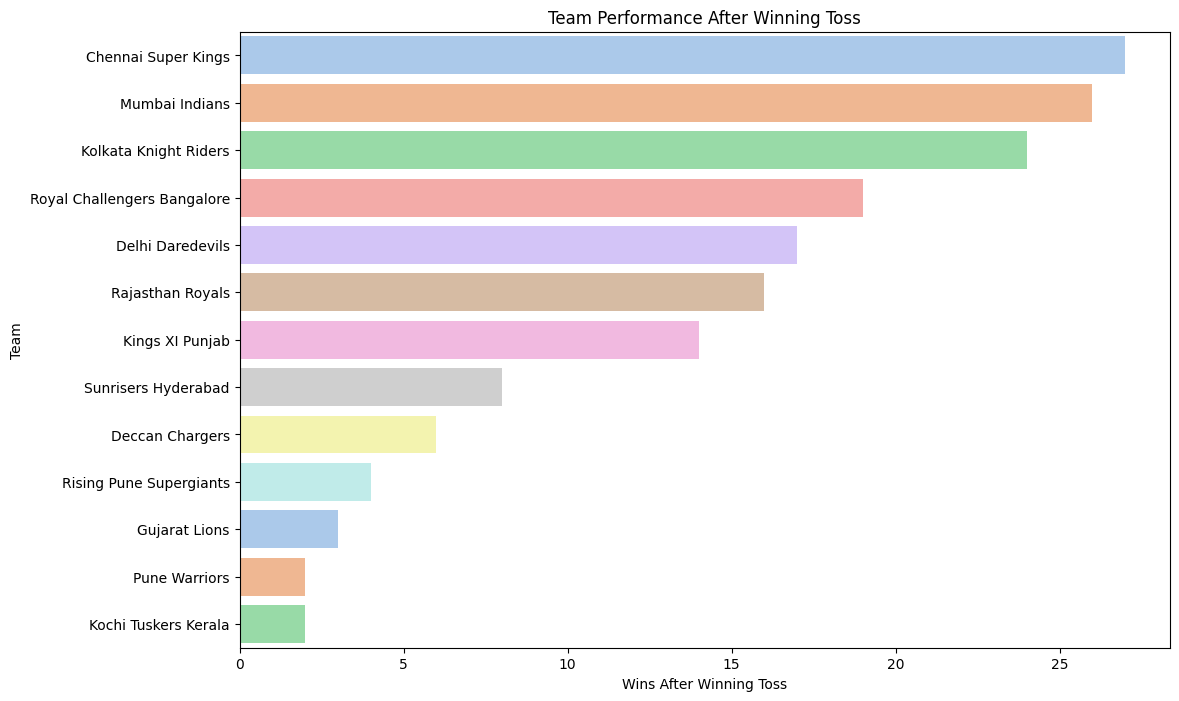

In [0]:
# Convert to Pandas DataFrame
team_toss_win_pd = team_toss_win_performance.toPandas()

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='wins_after_toss', y='team1', data=team_toss_win_pd,palette='pastel')
plt.title('Team Performance After Winning Toss')
plt.xlabel('Wins After Winning Toss')
plt.ylabel('Team')
plt.show()